# 03 — Feature Distributions

Distributions of each feature per park, correlation between features and labels, and NDVI coverage.
Input: `data/processed/featured_dataset.csv`

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

DATA = Path('../data/processed/featured_dataset.csv')
PLOTS = Path('../results/plots')
PLOTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA, index_col='date', parse_dates=True)
df_clean = df[df['ndvi_missing'] == 0].copy()

PARKS = ['yankari', 'cross_river', 'gashaka_gumti', 'kainji_lake', 'old_oyo', 'chad_basin']
PARK_LABELS = {
    'yankari': 'Yankari',
    'cross_river': 'Cross River',
    'gashaka_gumti': 'Gashaka-Gumti',
    'kainji_lake': 'Kainji Lake',
    'old_oyo': 'Old Oyo',
    'chad_basin': 'Chad Basin',
}
ECOSYSTEMS = {
    'yankari': 'savanna',
    'cross_river': 'rainforest',
    'gashaka_gumti': 'mixed',
    'kainji_lake': 'savanna',
    'old_oyo': 'savanna',
    'chad_basin': 'sahel',
}
ECO_COLORS = {
    'savanna': '#e9a24d',
    'rainforest': '#2a9d47',
    'mixed': '#8c6d3f',
    'sahel': '#c94040',
    'wetland': '#4d8fcc',
}
PARK_COLORS = {p: ECO_COLORS[ECOSYSTEMS[p]] for p in PARKS}

FEATURE_COLS = [
    'rain_7d', 'rain_30d', 'rain_60d', 'rain_deficit_30d',
    'temp_max_7d', 'temp_max_30d', 'hot_days_30d',
    'ndvi', 'ndvi_30d_lag', 'ndvi_change_30d', 'ndvi_90d_avg', 'ndvi_deviation',
    'fire_30d', 'fire_90d', 'days_since_fire',
    'doy_sin', 'doy_cos', 'dry_season',
]
LABEL_COLS = ['fire_within_30d', 'drought_within_30d', 'vegetation_within_30d']

print(f'Full dataset:  {len(df):,} rows')
print(f'NDVI-complete: {len(df_clean):,} rows ({len(df_clean)/len(df):.1%})')
print(f'Parks: {df["park"].nunique()} | Date range: {df.index.min().date()} → {df.index.max().date()}')

Full dataset:  12,792 rows
NDVI-complete: 11,541 rows (90.2%)
Parks: 6 | Date range: 2020-03-01 → 2025-12-31


## 1. NDVI Coverage per Park

Proportion of rows with valid NDVI (after 7-day forward-fill). Low coverage = high cloud cover.

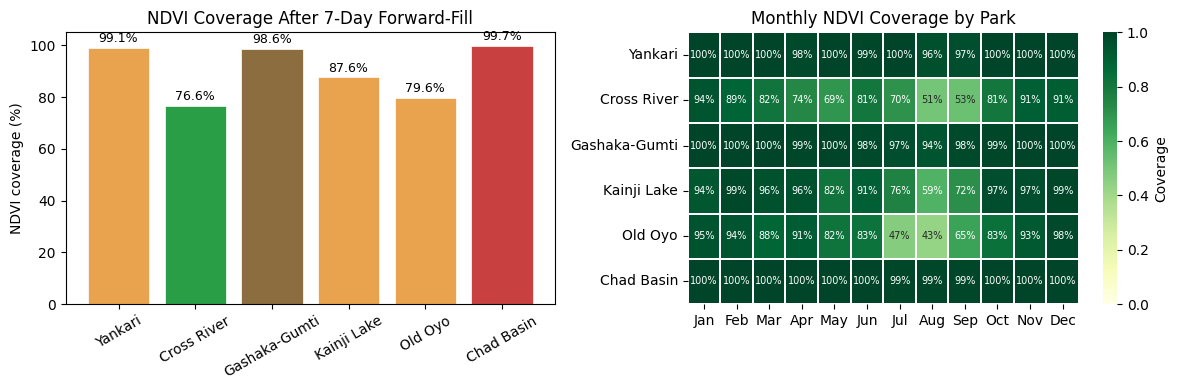

Saved ndvi_coverage.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Coverage bar chart
coverage = (
    df.groupby('park')['ndvi_missing']
    .apply(lambda x: 1 - x.mean())
    .reindex(PARKS)
)
colors = [PARK_COLORS[p] for p in coverage.index]
bars = axes[0].bar([PARK_LABELS[p] for p in coverage.index], coverage.values * 100, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('NDVI coverage (%)')
axes[0].set_title('NDVI Coverage After 7-Day Forward-Fill')
axes[0].set_ylim(0, 105)
for bar, val in zip(bars, coverage.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1%}',
                 ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Monthly NDVI availability heatmap
df['month'] = df.index.month
pivot = df.pivot_table(values='ndvi_missing', index='park', columns='month',
                        aggfunc=lambda x: 1 - x.mean())
pivot = pivot.reindex(PARKS)
pivot.index = [PARK_LABELS[p] for p in pivot.index]
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(pivot, ax=axes[1], cmap='YlGn', vmin=0, vmax=1,
            annot=True, fmt='.0%', annot_kws={'size': 7},
            linewidths=0.3, cbar_kws={'label': 'Coverage'})
axes[1].set_title('Monthly NDVI Coverage by Park')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(PLOTS / 'ndvi_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ndvi_coverage.png')

## 2. Climate Feature Distributions by Park

Boxplots for the 7 climate features, coloured by ecosystem type.

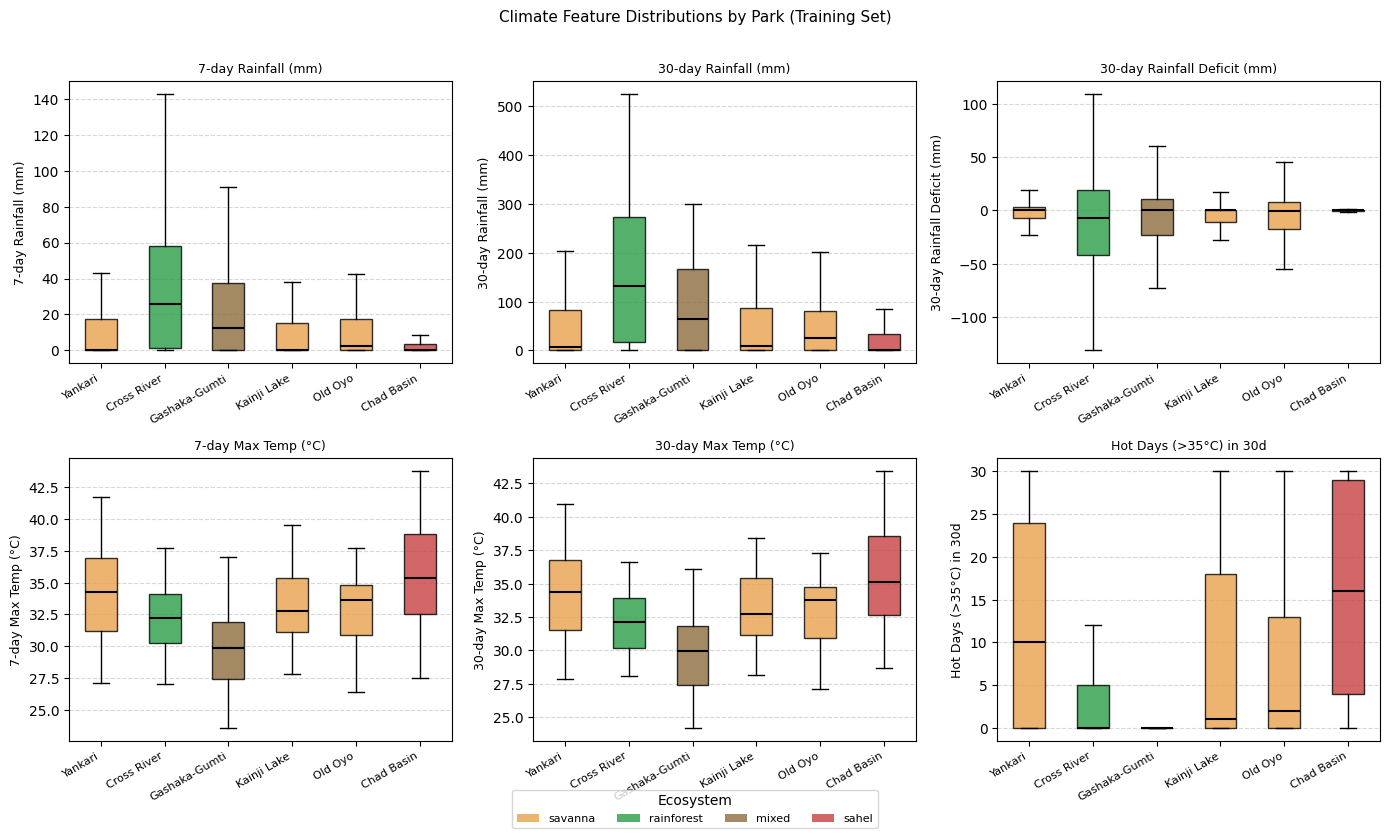

Saved climate_distributions.png


In [9]:
CLIMATE_FEATURES = [
    ('rain_7d',         '7-day Rainfall (mm)'),
    ('rain_30d',        '30-day Rainfall (mm)'),
    ('rain_deficit_30d','30-day Rainfall Deficit (mm)'),
    ('temp_max_7d',     '7-day Max Temp (°C)'),
    ('temp_max_30d',    '30-day Max Temp (°C)'),
    ('hot_days_30d',    'Hot Days (>35°C) in 30d'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, CLIMATE_FEATURES):
    data_by_park = [df_clean[df_clean['park'] == p][feat].dropna().values for p in PARKS]
    bp = ax.boxplot(data_by_park, patch_artist=True, showfliers=False,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, park in zip(bp['boxes'], PARKS):
        patch.set_facecolor(PARK_COLORS[park])
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(PARKS)+1))
    ax.set_xticklabels([PARK_LABELS[p] for p in PARKS], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Legend for ecosystems
eco_handles = [plt.Rectangle((0,0),1,1, facecolor=c, alpha=0.8, label=e)
               for e, c in ECO_COLORS.items() if e in ECOSYSTEMS.values()]
fig.legend(handles=eco_handles, title='Ecosystem', loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=8)

fig.suptitle('Climate Feature Distributions by Park (Training Set)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS / 'climate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved climate_distributions.png')

## 3. NDVI Feature Distributions by Park

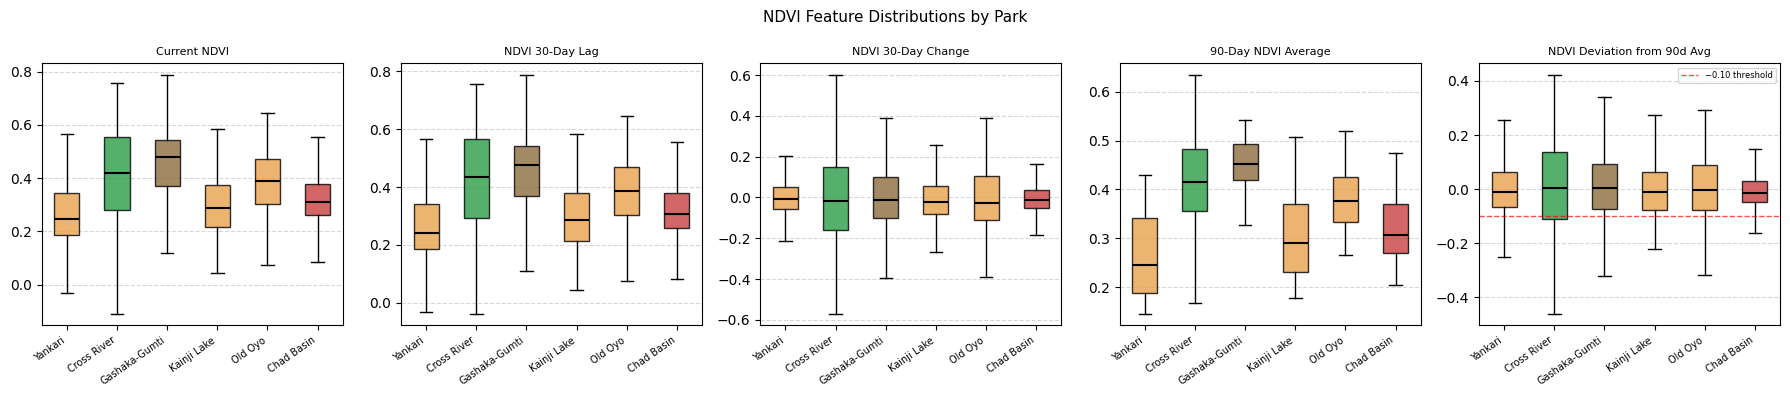

Saved ndvi_distributions.png


In [10]:
NDVI_FEATURES = [
    ('ndvi',            'Current NDVI'),
    ('ndvi_30d_lag',    'NDVI 30-Day Lag'),
    ('ndvi_change_30d', 'NDVI 30-Day Change'),
    ('ndvi_90d_avg',    '90-Day NDVI Average'),
    ('ndvi_deviation',  'NDVI Deviation from 90d Avg'),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (feat, label) in zip(axes, NDVI_FEATURES):
    data_by_park = [df_clean[df_clean['park'] == p][feat].dropna().values for p in PARKS]
    bp = ax.boxplot(data_by_park, patch_artist=True, showfliers=False,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, park in zip(bp['boxes'], PARKS):
        patch.set_facecolor(PARK_COLORS[park])
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(PARKS)+1))
    ax.set_xticklabels([PARK_LABELS[p] for p in PARKS], rotation=35, ha='right', fontsize=7)
    ax.set_title(label, fontsize=8)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    if feat in ('ndvi_deviation',):
        ax.axhline(-0.10, color='red', linestyle='--', linewidth=1, alpha=0.7, label='−0.10 threshold')
        ax.legend(fontsize=6)

fig.suptitle('NDVI Feature Distributions by Park', fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS / 'ndvi_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ndvi_distributions.png')

## 4. Fire Feature Distributions by Park

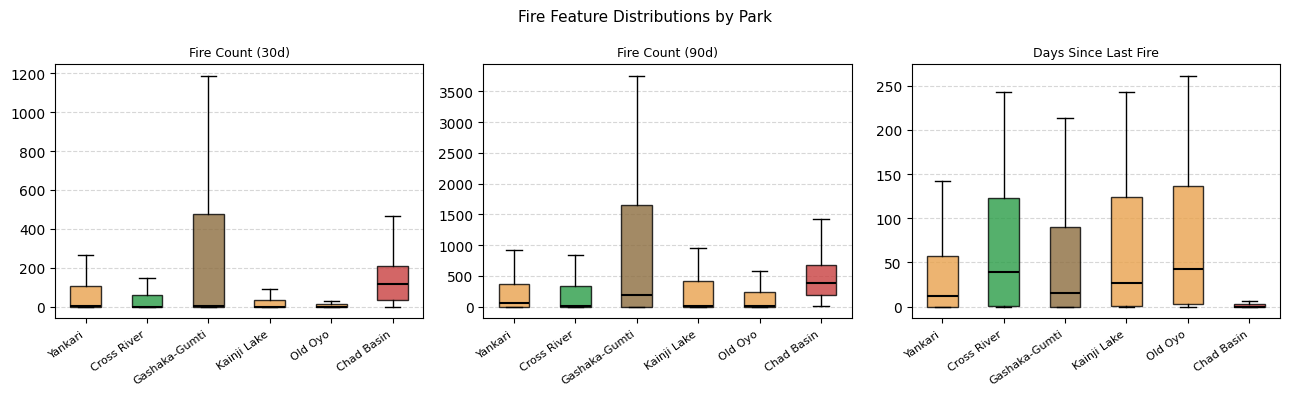

Saved fire_distributions.png


In [11]:
FIRE_FEATURES = [
    ('fire_30d',      'Fire Count (30d)'),
    ('fire_90d',      'Fire Count (90d)'),
    ('days_since_fire','Days Since Last Fire'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (feat, label) in zip(axes, FIRE_FEATURES):
    data_by_park = [df_clean[df_clean['park'] == p][feat].dropna().values for p in PARKS]
    bp = ax.boxplot(data_by_park, patch_artist=True, showfliers=False,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, park in zip(bp['boxes'], PARKS):
        patch.set_facecolor(PARK_COLORS[park])
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(PARKS)+1))
    ax.set_xticklabels([PARK_LABELS[p] for p in PARKS], rotation=35, ha='right', fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Fire Feature Distributions by Park', fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS / 'fire_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fire_distributions.png')

## 5. Feature–Label Correlation (Point-Biserial)

For each continuous feature, compute point-biserial correlation with each binary label.
Rows where the label is NaN are excluded. Results shown as a heatmap.

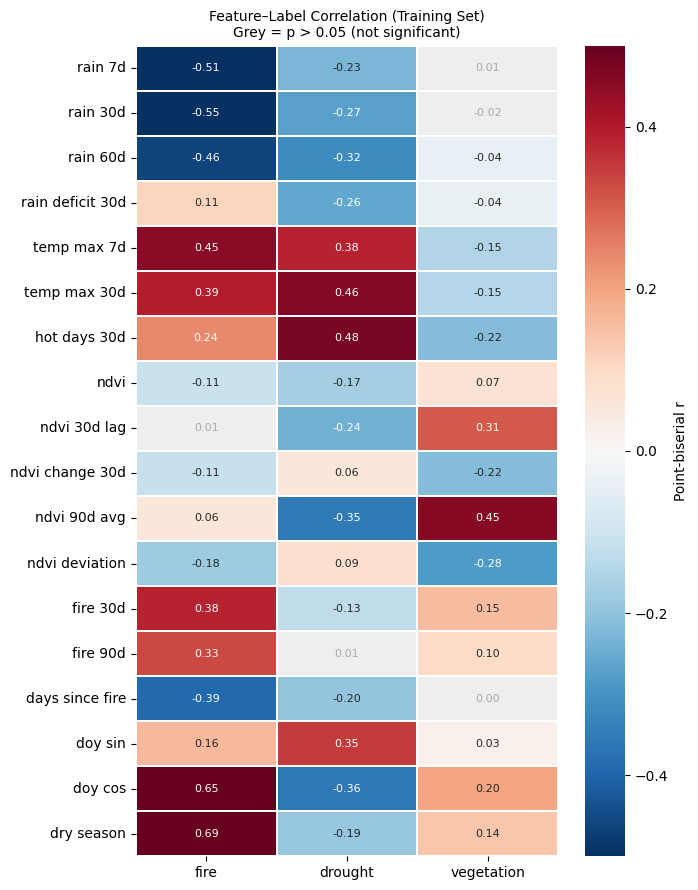


Top 5 correlates per label (training set):
  fire: dry_season(+0.69), doy_cos(+0.65), rain_30d(-0.55), rain_7d(-0.51), rain_60d(-0.46)
  drought: hot_days_30d(+0.48), temp_max_30d(+0.46), temp_max_7d(+0.38), doy_cos(-0.36), ndvi_90d_avg(-0.35)
  vegetation: ndvi_90d_avg(+0.45), ndvi_30d_lag(+0.31), ndvi_deviation(-0.28), hot_days_30d(-0.22), ndvi_change_30d(-0.22)

Saved feature_label_correlation.png


In [12]:
corr_matrix = pd.DataFrame(index=FEATURE_COLS, columns=LABEL_COLS, dtype=float)
pval_matrix = pd.DataFrame(index=FEATURE_COLS, columns=LABEL_COLS, dtype=float)

df_train = df_clean[df_clean['split'] == 'train']

for label in LABEL_COLS:
    sub = df_train[df_train[label].notna()]
    y = sub[label].astype(float)
    for feat in FEATURE_COLS:
        valid = sub[feat].notna()
        if valid.sum() < 30:
            corr_matrix.loc[feat, label] = np.nan
            pval_matrix.loc[feat, label] = np.nan
        else:
            x_vals = sub.loc[valid, feat].values
            y_vals = y.loc[valid].values
            r, p = stats.pointbiserialr(y_vals, x_vals)
            corr_matrix.loc[feat, label] = r
            pval_matrix.loc[feat, label] = p

# Clean column names for display
display_labels = [l.replace('_within_30d', '') for l in LABEL_COLS]
display_feats  = [f.replace('_', ' ') for f in FEATURE_COLS]

fig, ax = plt.subplots(figsize=(7, 9))
corr_vals = corr_matrix.astype(float)
sig_mask = pval_matrix.astype(float) > 0.05  # mask non-significant cells

sns.heatmap(
    corr_vals, ax=ax, cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.3, cbar_kws={'label': 'Point-biserial r'},
    xticklabels=display_labels, yticklabels=display_feats,
    mask=sig_mask
)
# Re-draw non-significant cells greyed out
sns.heatmap(
    corr_vals, ax=ax, cmap=['#eeeeee'], center=0,
    annot=True, fmt='.2f', annot_kws={'size': 8, 'color': '#aaaaaa'},
    linewidths=0.3, cbar=False,
    xticklabels=display_labels, yticklabels=display_feats,
    mask=~sig_mask
)

ax.set_title('Feature–Label Correlation (Training Set)\nGrey = p > 0.05 (not significant)', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS / 'feature_label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 correlates per label (training set):')
for label, display in zip(LABEL_COLS, display_labels):
    ranked = corr_vals[label].dropna().abs().sort_values(ascending=False).head(5)
    print(f'  {display}:', ', '.join(f'{f}({corr_vals.loc[f, label]:+.2f})' for f in ranked.index))
print('\nSaved feature_label_correlation.png')

## 6. Feature–Feature Correlation Heatmap

Pearson correlation among continuous features (training set). Identify multicollinearity.

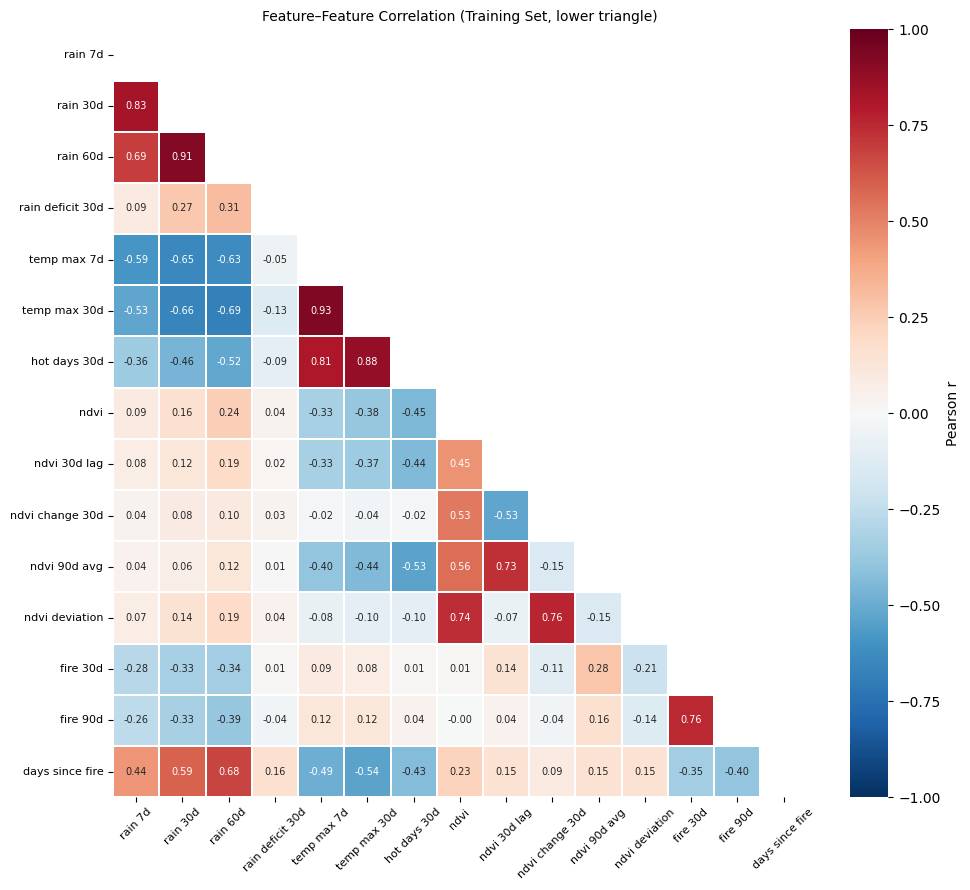

High multicollinearity (|r| > 0.80):
  temp_max_7d ↔ temp_max_30d: +0.932
  rain_30d ↔ rain_60d: +0.914
  temp_max_30d ↔ hot_days_30d: +0.877
  rain_7d ↔ rain_30d: +0.830
  temp_max_7d ↔ hot_days_30d: +0.807

Saved feature_feature_correlation.png


In [13]:
CONT_FEATS = [f for f in FEATURE_COLS if f not in ('doy_sin', 'doy_cos', 'dry_season', 'park_id', 'ecosystem_id')]

ff_corr = df_train[CONT_FEATS].corr()
display_cont = [f.replace('_', ' ') for f in CONT_FEATS]

mask = np.triu(np.ones_like(ff_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    ff_corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.2, cbar_kws={'label': 'Pearson r'},
    xticklabels=display_cont, yticklabels=display_cont,
    mask=mask
)
ax.set_title('Feature–Feature Correlation (Training Set, lower triangle)', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(PLOTS / 'feature_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag high multicollinearity
high_corr = []
for i, f1 in enumerate(CONT_FEATS):
    for f2 in CONT_FEATS[i+1:]:
        r = ff_corr.loc[f1, f2]
        if abs(r) > 0.80:
            high_corr.append((f1, f2, r))

if high_corr:
    print('High multicollinearity (|r| > 0.80):')
    for f1, f2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {f1} ↔ {f2}: {r:+.3f}')
else:
    print('No feature pairs with |r| > 0.80')
print('\nSaved feature_feature_correlation.png')

## 7. Seasonal Patterns of Climate Features

Monthly mean ± 1 std of key climate features per park. Shows how features behave over the year.

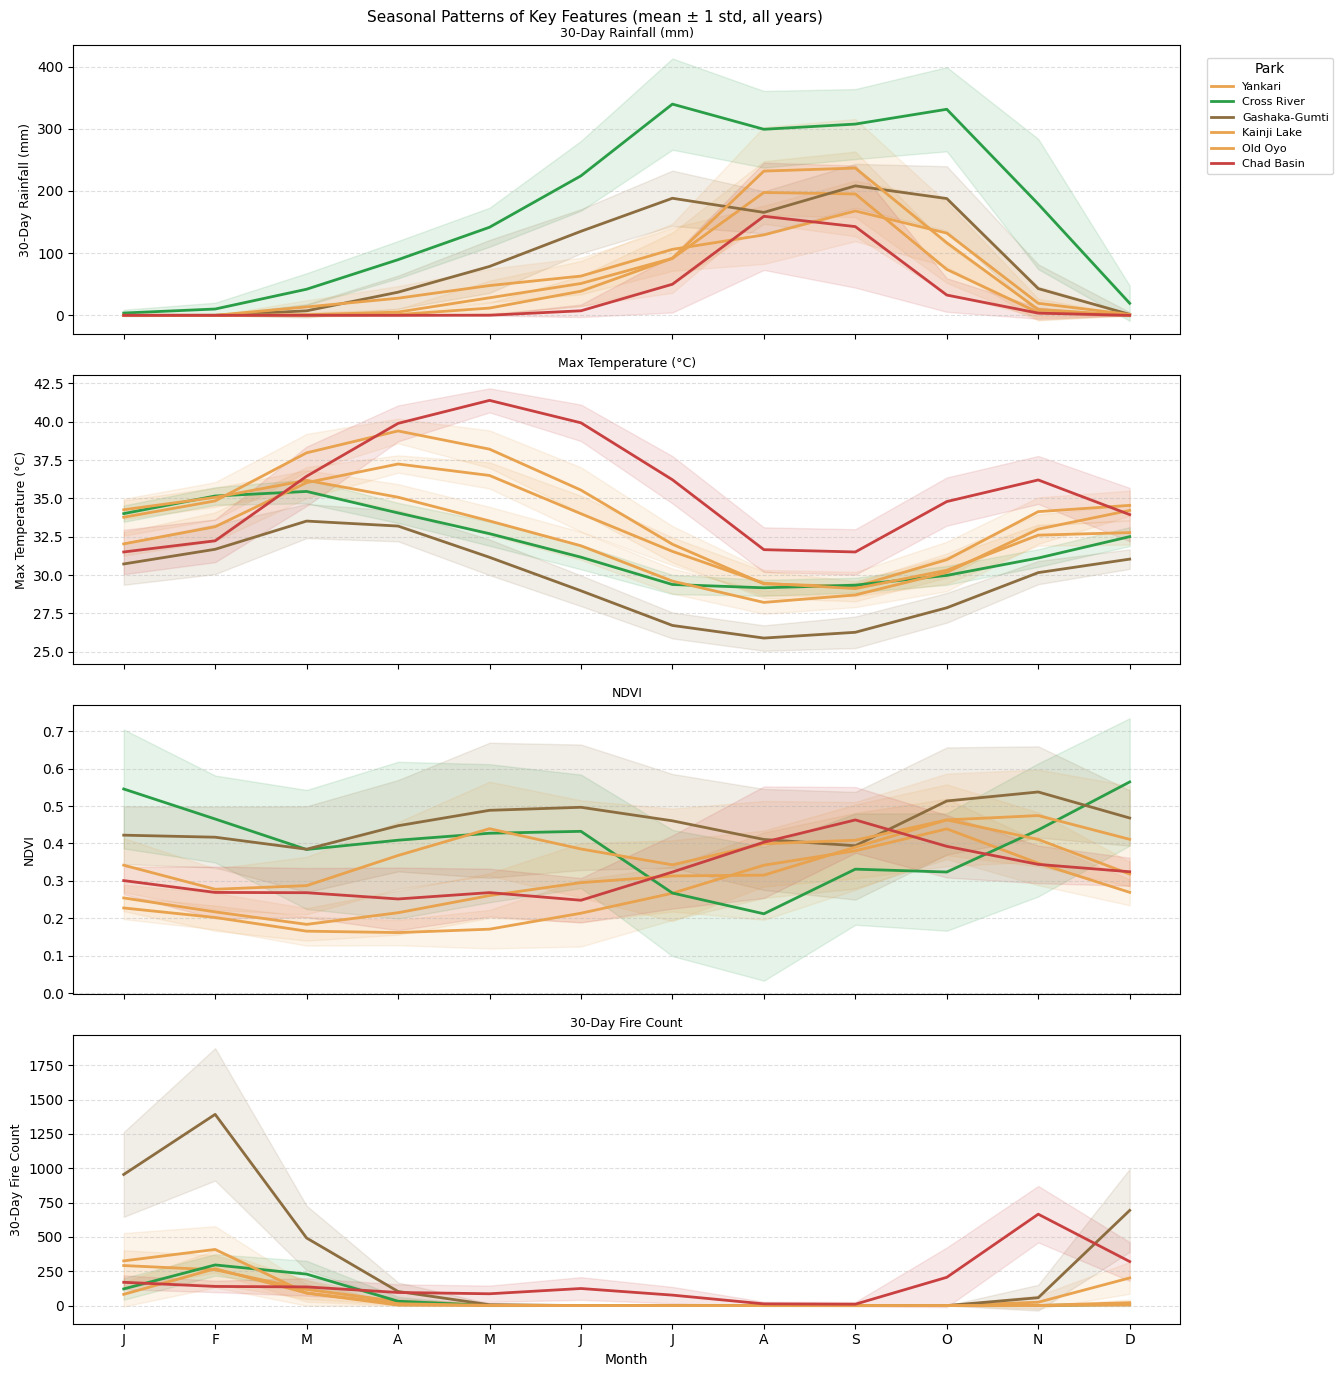

Saved seasonal_feature_patterns.png


In [14]:
SEASONAL_FEATS = ['rain_30d', 'temp_max_30d', 'ndvi', 'fire_30d']
FEAT_TITLES    = ['30-Day Rainfall (mm)', 'Max Temperature (°C)', 'NDVI', '30-Day Fire Count']

df_plot = df_clean.copy()
df_plot['month'] = df_plot.index.month

fig, axes = plt.subplots(len(SEASONAL_FEATS), 1, figsize=(12, 14), sharex=True)

months = range(1, 13)
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

for ax, feat, title in zip(axes, SEASONAL_FEATS, FEAT_TITLES):
    for park in PARKS:
        park_df = df_plot[df_plot['park'] == park]
        monthly = park_df.groupby('month')[feat]
        means = monthly.mean()
        stds  = monthly.std()
        ax.plot(list(months), means.reindex(months).values,
                label=PARK_LABELS[park], color=PARK_COLORS[park], linewidth=2)
        ax.fill_between(
            list(months),
            (means - stds).reindex(months).values,
            (means + stds).reindex(months).values,
            alpha=0.12, color=PARK_COLORS[park]
        )
    ax.set_ylabel(title, fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_title(title, fontsize=9)

axes[-1].set_xticks(list(months))
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel('Month')

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='upper right', bbox_to_anchor=(1.12, 0.95),
           title='Park', fontsize=8)
fig.suptitle('Seasonal Patterns of Key Features (mean ± 1 std, all years)', fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS / 'seasonal_feature_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved seasonal_feature_patterns.png')

## 8. Summary Statistics Table

Mean, std, min, and max of each feature in the training set, split by ecosystem type.

In [15]:
df_train_eco = df_train.copy()
eco_map = {p: ECOSYSTEMS[p] for p in PARKS}
df_train_eco['ecosystem'] = df_train_eco['park'].map(eco_map)

CONT_FEATS_DISP = ['rain_7d', 'rain_30d', 'rain_deficit_30d',
                   'temp_max_7d', 'hot_days_30d',
                   'ndvi', 'ndvi_deviation',
                   'fire_30d', 'days_since_fire']

summary_rows = []
for eco in ['savanna', 'rainforest', 'mixed', 'sahel']:
    sub = df_train_eco[df_train_eco['ecosystem'] == eco][CONT_FEATS_DISP]
    row = {'ecosystem': eco, 'n_rows': len(sub)}
    for feat in CONT_FEATS_DISP:
        v = sub[feat].dropna()
        row[feat] = f'{v.mean():.2f} ± {v.std():.2f}'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('ecosystem')
print('Summary statistics by ecosystem (mean ± std, training set):')
print(summary_df.to_string())

summary_path = Path('../results') / 'feature_summary_by_ecosystem.csv'
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(summary_path)
print(f'\nSaved → {summary_path}')

Summary statistics by ecosystem (mean ± std, training set):
            n_rows        rain_7d         rain_30d rain_deficit_30d   temp_max_7d   hot_days_30d         ndvi ndvi_deviation         fire_30d days_since_fire
ecosystem                                                                                                                                                    
savanna       3256  10.84 ± 20.27    46.79 ± 73.17    -2.17 ± 42.92  33.66 ± 3.08  10.45 ± 11.15  0.30 ± 0.13   -0.00 ± 0.11   57.55 ± 106.10   46.38 ± 60.61
rainforest     913  32.22 ± 33.99  142.59 ± 128.15    -8.32 ± 63.33  32.20 ± 2.35    4.66 ± 7.78  0.40 ± 0.17   -0.00 ± 0.17   66.17 ± 113.60   53.59 ± 64.99
mixed         1199  19.61 ± 22.86    82.39 ± 81.43    -4.57 ± 40.85  29.86 ± 2.78    0.73 ± 1.83  0.44 ± 0.14    0.00 ± 0.14  288.81 ± 426.94   48.94 ± 61.55
sahel         1211   5.22 ± 13.50    22.09 ± 45.01    -7.72 ± 32.67  35.81 ± 3.97  16.71 ± 11.39  0.32 ± 0.10    0.00 ± 0.09  166.98 ± 196.49     4.25